# 2D Connection Culvert Invert Validation (Terrain Cell Minimum)

In [1]:
#!pip install --upgrade ras-commander

## Development Mode

Set `USE_LOCAL_SOURCE = True` when running from a local ras-commander checkout.

In [2]:
USE_LOCAL_SOURCE = False
if USE_LOCAL_SOURCE:
    import sys
    from pathlib import Path
    cwd = Path.cwd()
    local_path = cwd if (cwd / "ras_commander").exists() else cwd.parent
    if str(local_path) not in sys.path:
        sys.path.insert(0, str(local_path))
    print(f"LOCAL SOURCE MODE: {local_path / 'ras_commander'}")
else:
    print("PIP PACKAGE MODE")

import logging
import os
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from shapely.geometry import LineString, Point

from ras_commander import RasExamples
from ras_commander.geom import GeomLateral, GeomCulvertGIS
from ras_commander.hdf import HdfMesh

warnings.filterwarnings("ignore", category=FutureWarning)
logging.getLogger("ras_commander").setLevel(logging.CRITICAL)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

import ras_commander
print(f"Loaded: {ras_commander.__file__}")

PIP PACKAGE MODE


c:\Users\bill\anaconda3\envs\rascommander\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded: G:\GH\ras-commander-wt-culv2d\ras_commander\__init__.py


# Validating culvert inverts on a 2D connection

In a 2D model, a culvert through an embankment is placed on a **SA/2D connection**
(the connection centerline is a real GIS cut line in the geometry). Before adding
or moving such a culvert, its invert must not sit **below the streambed** -- and in
2D the relevant streambed is the **minimum terrain elevation of the mesh cell** the
culvert end discharges into.

`GeomCulvertGIS` computes that cell minimum **directly from the terrain raster**
(`mesh_cell_min_from_terrain`), so the check works **without** running the HEC-RAS
2D geometry preprocessor and reflects any terrain modifications baked into the
raster. `validate_2d_inverts` then flags proposed inverts that fall below their
cell minimum.

This notebook runs entirely on mesh geometry + terrain -- **no HEC-RAS compute**.

## Load the model and pick a connection

We use `BaldEagleCrkMulti2D` and its **2D-to-2D** "Lower Levee" connection -- an
embankment inside the mesh, with cells on both sides (where culverts would
discharge).

In [3]:
WORK = Path(os.environ.get("RAS_COMMANDER_WORKDIR",
            (Path.cwd() if (Path.cwd() / "ras_commander").exists() else Path.cwd().parent)
            / "working" / "culvert_gis_2d"))
WORK.mkdir(parents=True, exist_ok=True)

project_path = Path(RasExamples.extract_project("BaldEagleCrkMulti2D", output_path=WORK,
                                                 suffix="culv2d"))
GEOM = project_path / "BaldEagleDamBrk.g01"
GEOM_HDF = project_path / "BaldEagleDamBrk.g01.hdf"

conns = GeomLateral.get_connections(GEOM)
display(conns[["Name", "Type", "From", "To", "NumPoints", "HasGate", "HasCulvert"]])

CONN = "Lower Levee"
line = GeomLateral.get_connection_line_coords(GEOM, CONN)
conn_ls = LineString(line[["X", "Y"]].to_numpy())
print(f"Connection '{CONN}': {len(line)} vertices, {conn_ls.length:,.0f} ft")

,Name,Type,From,To,NumPoints,HasGate,HasCulvert
0,Dam,SA to 2D,Reservoir Pool,BaldEagleCr,10,True,False
1,Lower Levee,2D to 2D,BaldEagleCr,BaldEagleCr,94,False,False
2,Middle Levee,2D to 2D,BaldEagleCr,BaldEagleCr,122,False,False
3,Upper Levee,2D to 2D,BaldEagleCr,BaldEagleCr,99,False,False


Connection 'Lower Levee': 89 vertices, 15,808 ft


## The connection cut line over the 2D mesh

3,329 mesh cells within 800 ft of the connection (of 87,039)


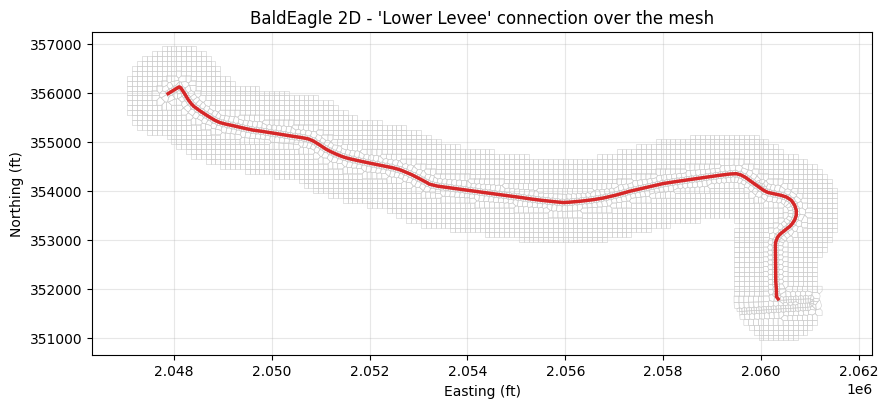

In [4]:
mesh_crs = HdfMesh.get_mesh_cell_polygons(GEOM_HDF).crs
cells = HdfMesh.get_mesh_cell_polygons(GEOM_HDF)
# clip cells to a buffer around the connection for a readable plan view
buf = conn_ls.buffer(800)
near = cells[cells.intersects(buf)]
print(f"{len(near):,} mesh cells within 800 ft of the connection (of {len(cells):,})")

fig, ax = plt.subplots(figsize=(9, 7))
near.boundary.plot(ax=ax, color="0.8", linewidth=0.4)
gpd.GeoSeries([conn_ls], crs=mesh_crs).plot(ax=ax, color="C3", linewidth=2.5)
ax.set_title(f"BaldEagle 2D - '{CONN}' connection over the mesh")
ax.set_xlabel("Easting (ft)"); ax.set_ylabel("Northing (ft)")
ax.set_aspect("equal", adjustable="box"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Terrain minimum of the cell at each culvert location

Sample candidate culvert locations along the connection and compute the terrain
minimum of the mesh cell each one sits in -- the elevation a culvert invert must
stay at or above. This is the envelope a valid invert cannot drop below.

,point,cell_id,dist_ft,cell_terrain_min
0,0,86034,1580.79,558.69
1,1,86120,3688.51,537.62
2,2,86204,5796.22,538.06
3,3,86288,7903.94,538.47
4,4,86372,10011.66,540.47
5,5,86459,12119.38,539.12
6,6,86542,14227.10,547.28


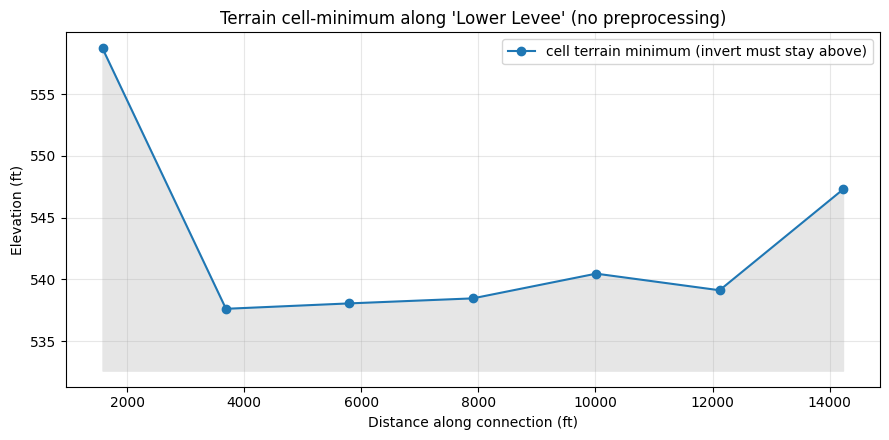

In [5]:
n_sites = 7
sites = [(p.x, p.y) for p in
         (conn_ls.interpolate(d, normalized=True) for d in np.linspace(0.1, 0.9, n_sites))]
cmin = GeomCulvertGIS.mesh_cell_min_from_terrain(GEOM_HDF, sites)
cmin["dist_ft"] = [conn_ls.project(Point(x, y)) for x, y in sites]
display(cmin[["point", "cell_id", "dist_ft", "cell_terrain_min"]].round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(cmin["dist_ft"], cmin["cell_terrain_min"], marker="o", color="C0",
        label="cell terrain minimum (invert must stay above)")
ax.fill_between(cmin["dist_ft"], cmin["cell_terrain_min"],
                cmin["cell_terrain_min"].min() - 5, color="0.9")
ax.set_xlabel("Distance along connection (ft)")
ax.set_ylabel("Elevation (ft)")
ax.set_title(f"Terrain cell-minimum along '{CONN}' (no preprocessing)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Validate a proposed culvert: pre (too low) -> post (corrected)

A retrofit proposes culverts at these sites. **Pre:** all set to a single low
invert (a common drafting placeholder) -- several fall below their cell terrain
minimum. **Post:** each invert is raised to clear its local cell minimum.

In [6]:
floor = float(cmin["cell_terrain_min"].min())
pre_inverts = [floor - 1.0] * n_sites               # one low placeholder
post_inverts = [m + 0.5 for m in cmin["cell_terrain_min"]]  # 0.5 ft above local cell min

pre = GeomCulvertGIS.validate_2d_inverts(GEOM_HDF, sites, pre_inverts)
post = GeomCulvertGIS.validate_2d_inverts(GEOM_HDF, sites, post_inverts)
print("PRE  (single low invert):", pre["status"].value_counts().to_dict())
print("POST (raised to local cell min):", post["status"].value_counts().to_dict())
display(pre[["point", "cell_id", "cell_terrain_min", "invert", "status", "detail"]])

PRE  (single low invert): {'FAIL': 7}
POST (raised to local cell min): {'PASS': 7}


,point,cell_id,cell_terrain_min,invert,status,detail
0,0,86034,558.68750,536.625,FAIL,invert 536.62 is 22.06 ft below cell terrain m...
1,1,86120,537.62500,536.625,FAIL,invert 536.62 is 1.00 ft below cell terrain mi...
2,2,86204,538.06250,536.625,FAIL,invert 536.62 is 1.44 ft below cell terrain mi...
3,3,86288,538.46875,536.625,FAIL,invert 536.62 is 1.84 ft below cell terrain mi...
4,4,86372,540.46875,536.625,FAIL,invert 536.62 is 3.84 ft below cell terrain mi...
5,5,86459,539.12500,536.625,FAIL,invert 536.62 is 2.50 ft below cell terrain mi...
6,6,86542,547.28125,536.625,FAIL,invert 536.62 is 10.66 ft below cell terrain m...


### Plan view: failing vs corrected placements

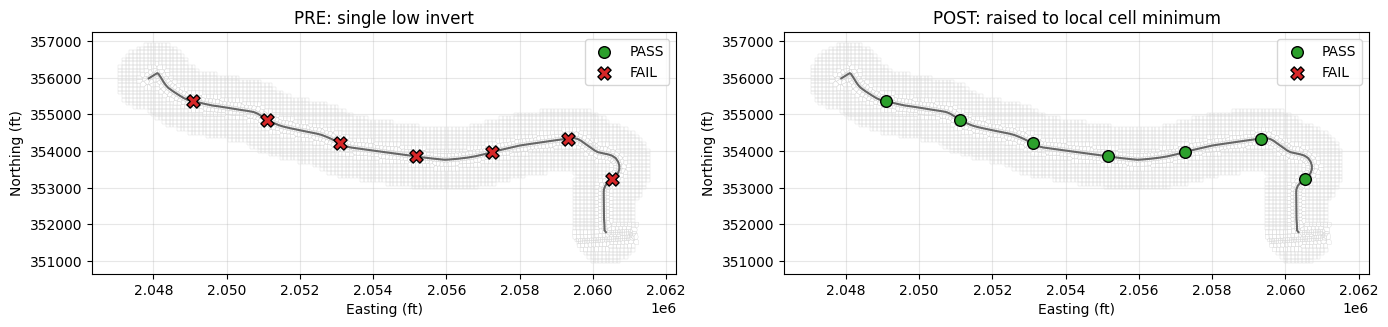

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, rep, title in [(axes[0], pre, "PRE: single low invert"),
                       (axes[1], post, "POST: raised to local cell minimum")]:
    near.boundary.plot(ax=ax, color="0.85", linewidth=0.3)
    gpd.GeoSeries([conn_ls], crs=mesh_crs).plot(ax=ax, color="0.4", linewidth=1.5)
    ok = rep[rep["status"] == "PASS"]
    bad = rep[rep["status"] == "FAIL"]
    ax.scatter(ok["x"], ok["y"], c="C2", s=70, zorder=5, label="PASS", edgecolor="k")
    ax.scatter(bad["x"], bad["y"], c="C3", s=90, marker="X", zorder=5, label="FAIL", edgecolor="k")
    ax.set_title(title); ax.set_aspect("equal", adjustable="box")
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_xlabel("Easting (ft)"); ax.set_ylabel("Northing (ft)")
plt.tight_layout(); plt.show()

## Summary

In [8]:
summary = pd.DataFrame([
    {"Design": "PRE (single low invert)", "invert basis": f"{floor - 1.0:.1f} ft (flat)",
     "PASS": int((pre["status"] == "PASS").sum()), "FAIL": int((pre["status"] == "FAIL").sum())},
    {"Design": "POST (raised to local cell min)", "invert basis": "local cell min + 0.5 ft",
     "PASS": int((post["status"] == "PASS").sum()), "FAIL": int((post["status"] == "FAIL").sum())},
])
display(summary)
print("The terrain cell-minimum check (no HEC-RAS preprocessing) flags culvert "
      "inverts set below the streambed of their 2D discharge cell, and confirms "
      "the corrected placement. 2D connection invert-validation workflow complete.")

,Design,invert basis,PASS,FAIL
0,PRE (single low invert),536.6 ft (flat),0,7
1,POST (raised to local cell min),local cell min + 0.5 ft,7,0


The terrain cell-minimum check (no HEC-RAS preprocessing) flags culvert inverts set below the streambed of their 2D discharge cell, and confirms the corrected placement. 2D connection invert-validation workflow complete.
